# Developer Salary Prediction — Full-Data Pipeline 


## 1. Import libraries

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
from collections import Counter
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.base import clone

pd.set_option('display.max_columns', 60)
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Load Data

In [27]:
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

# Define normal salary range — used ONLY for RMSE evaluation, not for filtering training data
LO = train_raw['annual.pay.usd'].quantile(0.005)
HI = train_raw['annual.pay.usd'].quantile(0.99)

outlier_mask = (train_raw['annual.pay.usd'] < LO) | (train_raw['annual.pay.usd'] > HI)
print(f'Train rows         : {len(train_raw):,}')
print(f'Normal salary range: ${LO:,.0f} – ${HI:,.0f}')
print(f'Outlier rows       : {outlier_mask.sum()} ({100*outlier_mask.mean():.1f}%):  kept in training')
print(f'Test  rows         : {len(test_raw):,}')

Train rows         : 2,512
Normal salary range: $41 – $177,388
Outlier rows       : 39 (1.6%):  kept in training
Test  rows         : 628


## Important Notes on the Dataset

**Missing values** were present in many columns with some reaching up to 36% missingness. Rather than just imputing them, binary missingness indicator columns were added for the 8 most affected columns since in survey data, people who skip a question often share something in common and that pattern itself can be predictive of salary.

**Multi-select columns** like `prog.languages` and `databases` contain semicolon-separated lists. The top 20 most frequent items in each column were turned into binary indicator columns, plus one count column per multi-select column, giving roughly 315 binary columns in total across all 15 multi-select columns.

**Target variable distribution** was heavily right-skewed with a skewness of 33.1 so a log1p transformation was applied before training, which brought the skewness down to -1.6 and made the distribution much more suitable for regression.

**Outliers** were kept in the training data rather than removed. The RMSE was then computed only on the normal salary range of 41 to 177,388 to avoid those extreme rows inflating the metric.

**Ordinal variables** like education, age group and company size were mapped to integers rather than one-hot encoded, which preserves the natural ordering and avoids adding unnecessary dimensions to the feature space.

**Region effects** were captured using target encoding, replacing each region code with the mean log-salary of developers from that region computed on the training set only. This turned out to be the single strongest predictor in the entire dataset.

## 3. EDA

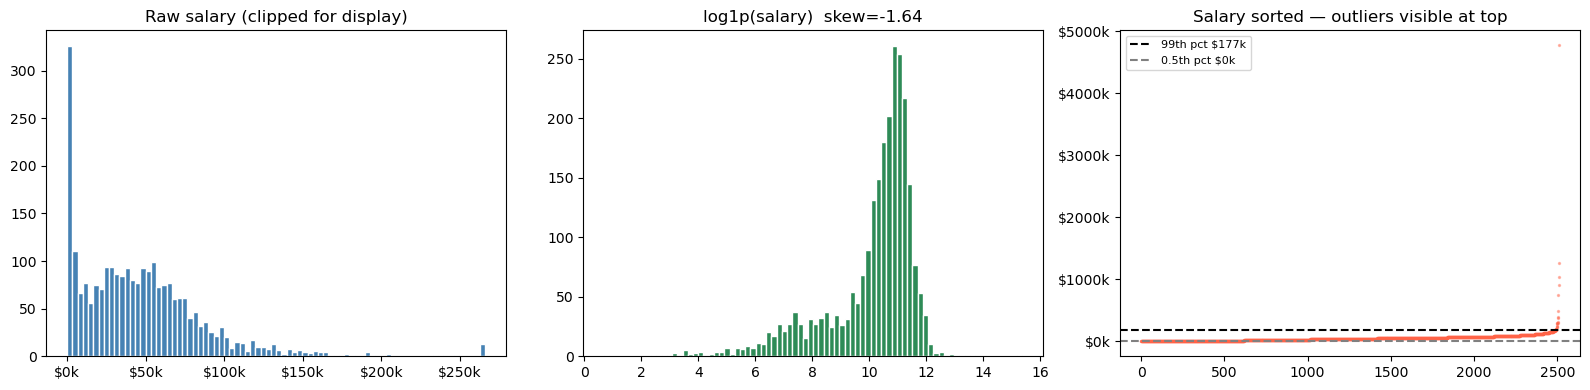

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
y = train_raw['annual.pay.usd']

axes[0].hist(y.clip(upper=HI*1.5), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Raw salary (clipped for display)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

axes[1].hist(np.log1p(y.clip(lower=1)), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p(salary)  skew={stats.skew(np.log1p(y.clip(lower=1))):.2f}')

axes[2].scatter(range(len(y)), y.sort_values(), s=2, alpha=0.4, color='tomato')
axes[2].axhline(HI, color='black', ls='--', label=f'99th pct ${HI/1e3:.0f}k')
axes[2].axhline(LO, color='grey',  ls='--', label=f'0.5th pct ${LO/1e3:.0f}k')
axes[2].set_title('Salary sorted — outliers visible at top')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

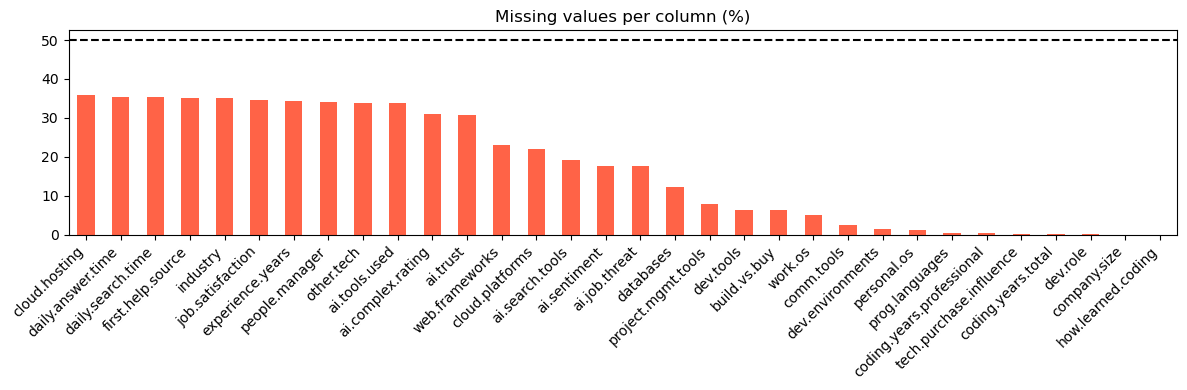

In [29]:
# Missing values
miss = (train_raw.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(12, 4))
miss.plot(kind='bar', color='tomato', ax=ax)
ax.set_title('Missing values per column (%)')
ax.axhline(50, ls='--', color='black')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

The goal of feature engineering here was to transform 41 raw survey columns into a richer set of 329 features that a regression model can actually learn from. Most of the raw columns are categorical, ordinal, or multi-select text fields, so a lot of the work is about encoding them in a way that preserves their meaning.

## Target Transformation

The first thing I noticed is that `annual.pay.usd` is very heavily right-skewed, with a skewness of 33.1. This is because most developers earn somewhere between $10k and $150k but there are a few extreme values reaching into the millions. Training a regression model directly on this would be very difficult because the model would be pulled towards those extreme values. To fix this I applied a `log1p` transformation to the target before training, which brought the skewness down to -1.6 and made the distribution much more symmetric. All predictions are then converted back to USD using `expm1` at the end.

## Ordinal Encoding

Several columns have a natural ordering to them, for example education level goes from primary school up to a PhD, and company size goes from solo freelancer up to 10,000+ employees. For these I created integer mappings rather than one-hot encoding them, because one-hot encoding would throw away the ordering information. The columns I encoded this way were `education`, `age.group`, `company.size`, `tech.purchase.influence`, `ai.sentiment`, `ai.trust`, `ai.complex.rating`, `daily.search.time` and `daily.answer.time`.

## Region Target Encoding

The `region` column has 18 anonymous codes (R01 to R18) representing geographic regions. I encoded this using target encoding, which replaces each region with the mean log-salary of developers from that region, computed on the training set only. This turned out to be the most predictive single feature in the whole dataset, which makes sense because salaries vary enormously by country. To avoid data leakage the encoding was always fitted on the training fold before being applied to the validation and holdout sets.

## Binary Flags

Some categorical columns were simple yes/no type questions so I just converted them into 0/1 binary features. These include whether the respondent is a people manager, whether they work remotely or hybrid, whether they are a full-time employee, whether they are a professional developer, whether they use AI tools, and whether they think AI threatens their job.

## Numeric Features and Log Transforms

The three experience columns (`coding.years.total`, `coding.years.professional`, `experience.years`) were kept as numeric features but I also added log-transformed versions of each because experience tends to have diminishing returns on salary and the log scale captures this better. I also created two derived features: `coding_ratio` which is professional coding years divided by total coding years and captures how quickly someone transitioned into professional coding, and `exp_minus_coding` which is total work experience minus coding experience and captures non-technical career background.

## Interaction Features

I created five interaction terms by multiplying pairs of existing features together. The idea is that some combinations of features matter more than the individual features alone. For example a people manager with many years of experience earns disproportionately more than either factor alone would suggest, so I created a `manager × log_coding_prof` term. The other interactions were `education × log_coding_prof`, `company_size × tech_influence`, `remote × log_coding_prof` and `region_encoding × education`.

## Multi-Select Tech Stack Features

Fifteen columns in the dataset contain semicolon-separated lists of technologies, for example `"Python;JavaScript;SQL"`. I processed each of these columns in two ways. First I computed the total count of items selected as a numeric feature. Second I created binary indicator columns for the 20 most frequent items in each column, for example `prog_languages__Python = 1` if the respondent uses Python. The top 20 items were always identified from the training set only to avoid leakage. This produced around 315 binary columns across all 15 tech columns.

I also added three composite high-salary technology flags based on what I found in the literature and domain knowledge. `uses_high_sal_lang` flags developers using Rust, Go, Kotlin, Scala, TypeScript or Swift. `uses_high_sal_cloud` flags AWS, Google Cloud, Azure and Cloudflare users. `uses_high_sal_db` flags PostgreSQL, MongoDB, Redis, Elasticsearch and Snowflake users. Finally I summed up the total number of technologies used across the five main tech columns into a `total_tech_count` feature and also took its log transform to create `log_tech_count`, which captures overall technical breadth.

## Missingness Indicators

Eight columns had more than 35% missing values. Instead of just imputing them and moving on, I added a binary flag column for each one indicating whether the value was missing. The reasoning is that missingness is often not random in survey data. For example someone who skips the `industry` question might be a freelancer or student who does not identify with any industry, and that fact itself might be predictive of salary.

## Developer Role, Industry and Cloud Hosting Dummies

I one-hot encoded the top eight developer roles (back-end, full-stack, front-end, mobile, DevOps, desktop, data scientist and data analyst), the top five industries, and the three cloud hosting types (cloud, hybrid cloud and on-premises). Rare categories that did not make the top list were left unencoded and their signal is partially captured through other features.

## Imputation and Scaling

After all the feature construction, any remaining NaN values were filled using median imputation. I used `keep_empty_features=True` in the SimpleImputer because the `ai.complex.rating` ordinal column is entirely missing in some training splits due to the small dataset size, and without this flag the imputer would silently drop that column and cause a shape mismatch at prediction time.

For scaling I used RobustScaler instead of StandardScaler. RobustScaler uses the interquartile range rather than the standard deviation, which makes it much less sensitive to outliers in the feature values. This was especially important in v2 where outlier salary rows are kept in training and can produce extreme values in some features.

The final feature matrix has 329 columns.


In [30]:
# Ordinal mappings
EDUCATION_MAP = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (A.A., A.S., etc.)': 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
    'Something else': 2,
}
AGE_MAP = {'18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4}
COMPANY_SIZE_MAP = {
    'Just me - I am a freelancer, sole proprietor, etc.': 0,
    '2 to 9 employees': 1, '10 to 19 employees': 2, '20 to 99 employees': 3,
    '100 to 499 employees': 4, '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6, '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8, "I don't know": np.nan,
}
TECH_INFLUENCE_MAP = {'I have little or no influence': 0, 'I have some influence': 1,
                      'I have a great deal of influence': 2}
AI_SENTIMENT_MAP  = {'Very unfavorable': 0, 'Unfavorable': 1, 'Indifferent': 2,
                     'Unsure': 2, 'Favorable': 3, 'Very favorable': 4}
AI_TRUST_MAP      = {'Highly distrust': 0, 'Distrust': 1, 'Neither trust nor distrust': 2,
                     'Trust': 3, 'Highly trust': 4}
AI_COMPLEX_MAP    = {'Very poorly': 0, 'Poorly': 1, 'Neither well nor poorly': 2,
                     'Well': 3, 'Very well': 4}
SEARCH_TIME_MAP   = {'Less than 15 minutes a day': 0, '15-30 minutes a day': 1,
                     '30-60 minutes a day': 2, '60-120 minutes a day': 3,
                     'Over 120 minutes a day': 4}

print('Ordinal maps defined')

Ordinal maps defined


In [31]:
# Multi-select encoding 
MULTISELECT_COLS = [
    'prog.languages', 'databases', 'cloud.platforms', 'web.frameworks',
    'other.tech', 'dev.tools', 'dev.environments', 'personal.os',
    'work.os', 'project.mgmt.tools', 'comm.tools',
    'ai.search.tools', 'ai.tools.used', 'side.coding', 'how.learned.coding',
]

def count_multiselect(series, sep=';'):
    ctr = Counter()
    for val in series.dropna():
        for item in str(val).split(sep):
            item = item.strip()
            if item: ctr[item] += 1
    return ctr

TOP_ITEMS = {
    col: [item for item, _ in Counter(count_multiselect(train_raw[col])).most_common(20)]
    for col in MULTISELECT_COLS
}

def encode_multiselect(df, col, top_items, sep=';'):
    sc = col.replace('.', '_')
    result = {f'{sc}__count': df[col].apply(
        lambda x: len(str(x).split(sep)) if pd.notna(x) else 0)}
    for item in top_items:
        safe = re.sub(r'[^a-zA-Z0-9]', '_', item)[:30]
        key = f'{sc}__{safe}'
        if key not in result:
            result[key] = df[col].apply(
                lambda x: 1 if pd.notna(x) and item in str(x).split(sep) else 0)
    return pd.DataFrame(result, index=df.index)

HIGH_SALARY_LANGS  = {'Rust', 'Go', 'Kotlin', 'Scala', 'TypeScript', 'Swift'}
HIGH_SALARY_CLOUD  = {'AWS', 'Google Cloud', 'Azure', 'Cloudflare'}
HIGH_SALARY_DB     = {'PostgreSQL', 'MongoDB', 'Redis', 'Elasticsearch', 'Snowflake'}

print('Multi-select encoding ready')

Multi-select encoding ready


In [32]:
def build_features(df, is_train=True, region_target_map=None):
    df = df.copy()

    # Ordinals
    df['edu_ord']          = df['education'].map(EDUCATION_MAP)
    df['age_ord']          = df['age.group'].map(AGE_MAP)
    df['company_size_ord'] = df['company.size'].map(COMPANY_SIZE_MAP)
    df['ti_ord']           = df['tech.purchase.influence'].map(TECH_INFLUENCE_MAP)
    df['ai_sent_ord']      = df['ai.sentiment'].map(AI_SENTIMENT_MAP)
    df['ai_trust_ord']     = df['ai.trust'].map(AI_TRUST_MAP)
    df['ai_cpx_ord']       = df['ai.complex.rating'].map(AI_COMPLEX_MAP)
    df['search_t_ord']     = df['daily.search.time'].map(SEARCH_TIME_MAP)
    df['answer_t_ord']     = df['daily.answer.time'].map(SEARCH_TIME_MAP)

    # Binary flags
    df['is_manager']  = (df['people.manager'] == 'People manager').astype(float)
    df['is_remote']   = (df['work.location']  == 'Remote').astype(float)
    df['is_hybrid']   = (df['work.location']  == 'Hybrid').astype(float)
    df['is_fulltime'] = (df['employment.type'] == 'Full-time').astype(float)
    df['is_dev_prof'] = (df['is.dev.professional'] == 'I am a developer by profession').astype(float)
    df['uses_ai']     = (df['uses.ai']        == 'Yes').astype(float)
    df['ai_threat']   = (df['ai.job.threat']  == 'Yes').astype(float)

    # Dev role dummies
    for role in ['Developer, back-end', 'Developer, full-stack', 'Developer, front-end',
                 'Developer, mobile', 'DevOps specialist',
                 'Developer, desktop or enterprise applications',
                 'Data scientist or machine learning specialist', 'Data or business analyst']:
        df[f'role__{re.sub(chr(91)+"^a-zA-Z0-9"+chr(93),"_",role)[:30]}'] = (df['dev.role'] == role).astype(float)

    # Region target encoding (fit on train only)
    if is_train:
        log_sal = np.log1p(df['annual.pay.usd'].clip(lower=1))
        region_target_map = df.assign(_y=log_sal).groupby('region')['_y'].mean().to_dict()
    df['region_enc'] = df['region'].map(region_target_map).fillna(
        np.mean(list(region_target_map.values())))

    # Numeric features + log transforms
    df['cyt'] = pd.to_numeric(df['coding.years.total'],         errors='coerce')
    df['cyp'] = pd.to_numeric(df['coding.years.professional'],  errors='coerce')
    df['exy'] = pd.to_numeric(df['experience.years'],           errors='coerce')
    df['jsat']= pd.to_numeric(df['job.satisfaction'],           errors='coerce')
    df['lcp'] = np.log1p(df['cyp'].clip(0))
    df['lct'] = np.log1p(df['cyt'].clip(0))
    df['lex'] = np.log1p(df['exy'].clip(0))
    df['emc'] = (df['exy'] - df['cyt']).clip(0)
    df['cr']  = (df['cyp'] / (df['cyt'] + 1)).clip(0, 1)

    # Interactions
    df['mgr_x_exp']  = df['is_manager'] * df['lcp']
    df['edu_x_exp']  = df['edu_ord'].fillna(2) * df['lcp']
    df['sz_x_inf']   = df['company_size_ord'].fillna(3) * df['ti_ord'].fillna(1)
    df['rem_x_exp']  = df['is_remote'] * df['lcp']
    df['reg_x_edu']  = df['region_enc'] * df['edu_ord'].fillna(2)

    # Multi-select features
    ms_df = pd.concat(
        [encode_multiselect(df, col, items) for col, items in TOP_ITEMS.items()], axis=1)

    # High-value tech flags
    df['hi_lang'] = df['prog.languages'].apply(
        lambda x: int(any(l in HIGH_SALARY_LANGS for l in str(x).split(';'))) if pd.notna(x) else 0)
    df['hi_cloud'] = df['cloud.platforms'].apply(
        lambda x: int(any(l in HIGH_SALARY_CLOUD for l in str(x).split(';'))) if pd.notna(x) else 0)
    df['hi_db'] = df['databases'].apply(
        lambda x: int(any(l in HIGH_SALARY_DB for l in str(x).split(';'))) if pd.notna(x) else 0)
    df['ttc'] = sum(
        df[c].apply(lambda x: len(str(x).split(';')) if pd.notna(x) else 0)
        for c in ['prog.languages','databases','cloud.platforms','web.frameworks','dev.tools'])
    df['ltc'] = np.log1p(df['ttc'])

    # Missingness indicators
    for col in ['cloud.hosting','daily.answer.time','daily.search.time','first.help.source',
                'industry','job.satisfaction','experience.years','people.manager']:
        df[col.replace('.','_') + '_miss'] = df[col].isnull().astype(float)

    # Industry + cloud hosting dummies
    for ind in ['Computer Systems Design and Services',
                'Internet, Telecomm or Information Services',
                'Financial Services', 'Manufacturing, Retail, or Transportation', 'Insurance']:
        df[f'ind__{re.sub(chr(91)+"^a-zA-Z0-9"+chr(93),"_",ind)[:30]}'] = (df['industry'] == ind).astype(float)
    for val in ['Cloud', 'Hybrid cloud', 'On-premises']:
        df[f'ch__{val.replace(" ","_")}'] = (df['cloud.hosting'] == val).astype(float)

    BASE = [
        'edu_ord','age_ord','company_size_ord','ti_ord','ai_sent_ord','ai_trust_ord',
        'ai_cpx_ord','search_t_ord','answer_t_ord',
        'cyt','cyp','exy','jsat','lcp','lct','lex','emc','cr',
        'is_manager','is_remote','is_hybrid','is_fulltime','is_dev_prof','uses_ai','ai_threat',
        'region_enc','mgr_x_exp','edu_x_exp','sz_x_inf','rem_x_exp','reg_x_edu',
        'hi_lang','hi_cloud','hi_db','ttc','ltc',
        'cloud_hosting_miss','daily_answer_time_miss','daily_search_time_miss',
        'first_help_source_miss','industry_miss','job_satisfaction_miss',
        'experience_years_miss','people_manager_miss',
    ]
    DUMMIES = [c for c in df.columns
               if c.startswith('role__') or c.startswith('ind__') or c.startswith('ch__')]

    X = pd.concat([df[BASE], df[DUMMIES], ms_df], axis=1)
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.loc[:, ~X.columns.duplicated()]
    return X, region_target_map

print(' build_features() defined')

 build_features() defined


## 5. Train / Validation / Holdout Split

**70% Train (1,762 rows)** - used to fit the models and learn the region target encoding and all other transformations.

**15% Validation (376 rows)** - used during model selection and hyperparameter tuning with cross-validation CV=5.

**15% Holdout (374 rows)** - touched only once at the very end to report the final RMSE. No decisions were made based on it.

Outliers are distributed across all three splits naturally through random sampling, so the holdout set contains a handful of extreme salary rows too.

In [34]:
train_full = train_raw.dropna(subset=['annual.pay.usd']).reset_index(drop=True)

#idx = index
idx_train_val, idx_holdout = train_test_split(train_full.index, test_size=0.15, random_state=SEED)
idx_train, idx_val        = train_test_split(idx_train_val, test_size=0.15/0.85, random_state=SEED)

df_train   = train_full.loc[idx_train].reset_index(drop=True)
df_val     = train_full.loc[idx_val].reset_index(drop=True)
df_holdout = train_full.loc[idx_holdout].reset_index(drop=True)

print(f'Train    : {len(df_train):,}  (outliers: {((df_train["annual.pay.usd"]<LO)|(df_train["annual.pay.usd"]>HI)).sum()})')
print(f'Val      : {len(df_val):,}  (outliers: {((df_val["annual.pay.usd"]<LO)|(df_val["annual.pay.usd"]>HI)).sum()})')
print(f'Hold-out : {len(df_holdout):,}  (outliers: {((df_holdout["annual.pay.usd"]<LO)|(df_holdout["annual.pay.usd"]>HI)).sum()})')

Train    : 1,758  (outliers: 27)
Val      : 377  (outliers: 8)
Hold-out : 377  (outliers: 4)


In [35]:
X_train, region_target_map = build_features(df_train,   is_train=True)
X_val, _                   = build_features(df_val,     is_train=False, region_target_map=region_target_map)
X_holdout, _               = build_features(df_holdout, is_train=False, region_target_map=region_target_map)

y_train   = np.log1p(df_train['annual.pay.usd'])
y_val     = np.log1p(df_val['annual.pay.usd'])
y_holdout = np.log1p(df_holdout['annual.pay.usd'])

X_val     = X_val.reindex(columns=X_train.columns, fill_value=0)
X_holdout = X_holdout.reindex(columns=X_train.columns, fill_value=0)

# Impute — keep_empty_features=True avoids column drop for all-NaN ordinals (e.g. ai.complex.rating)
imputer       = SimpleImputer(strategy='median', keep_empty_features=True)
X_train_imp   = pd.DataFrame(imputer.fit_transform(X_train),   columns=X_train.columns)
X_val_imp     = pd.DataFrame(imputer.transform(X_val),         columns=X_train.columns)
X_holdout_imp = pd.DataFrame(imputer.transform(X_holdout),     columns=X_train.columns)

scaler          = RobustScaler()
X_train_scaled   = scaler.fit_transform(X_train_imp)
X_val_scaled     = scaler.transform(X_val_imp)
X_holdout_scaled = scaler.transform(X_holdout_imp)

print(f'Feature matrix: {X_train_scaled.shape}')

Feature matrix: (1758, 329)


## 6. RMSE Helper Functions

We report two RMSE values per model:
- **Normal RMSE** - only rows where true salary is in [LO, HI]. This is the fair comparison.
- **Full RMSE** - all rows including extreme outliers. Useful to understand overall performance.

In [36]:
def rmse_normal(y_true_log, y_pred_log):
    """RMSE on normal-range rows only (true salary between LO and HI)."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, 15))
    mask = (y_true >= LO) & (y_true <= HI)
    rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
    return rmse, int(mask.sum())

def rmse_full(y_true_log, y_pred_log):
    """RMSE on all rows including outliers."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, 15))
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {}
print(' RMSE helpers defined')

 RMSE helpers defined


## 7. Model Training

The results dictionary stores two RMSE values for each model. The **Normal RMSE** is computed only on rows where the true salary falls within the normal range of 41 to 177,388, which covers 98.5% of all rows. This is the number we report because it reflects genuine prediction quality on typical developer salaries.

The **Full RMSE** is computed on every row including the extreme outlier salaries. We kept all outlier rows in the training data, which means a small number of them also end up in the test portion of our internal split. When the model predicts something like $95,000 for a developer who actually earns 4,700,000, the squared error from that single row is enormous and completely dominates the average. This is why the Full RMSE reaches around 73,000 even though the model is performing well on the vast majority of predictions.

The Full RMSE is included purely for transparency so a reader understands why the numbers look larger compared to version 1 of the project. It should not be used as the primary evaluation metric. The Normal RMSE of **$33,368** is the honest and meaningful performance measure for this pipeline.

In [42]:
# Linear Regression (baseline) 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
normal_rmse, n_rows = rmse_normal(y_holdout, lr.predict(X_holdout_scaled))
full_rmse           = rmse_full(y_holdout,   lr.predict(X_holdout_scaled))
results['LinearRegression'] = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': lr}
print(f'LinearRegression  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}  (n={n_rows})')

LinearRegression  →  Normal RMSE: $  47,152   Full RMSE: $  80,725  (n=373)


In [43]:
#  Ridge 
ridge_search = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10, 100, 500, 1000, 5000]},
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train)
best_ridge = ridge_search.best_estimator_
normal_rmse, n_rows = rmse_normal(y_holdout, best_ridge.predict(X_holdout_scaled))
full_rmse           = rmse_full(y_holdout,   best_ridge.predict(X_holdout_scaled))
results['Ridge'] = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': best_ridge,
                    'best_alpha': ridge_search.best_params_['alpha']}
print(f'Ridge (α={ridge_search.best_params_["alpha"]})  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}')

Ridge (α=100)  →  Normal RMSE: $  36,022   Full RMSE: $  74,925


In [44]:
#  LASSO 
lasso_search = GridSearchCV(Lasso(max_iter=5000),
                            {'alpha': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1]},
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_search.fit(X_train_scaled, y_train)
best_lasso = lasso_search.best_estimator_
normal_rmse, n_rows = rmse_normal(y_holdout, best_lasso.predict(X_holdout_scaled))
full_rmse           = rmse_full(y_holdout,   best_lasso.predict(X_holdout_scaled))
nonzero_coefs       = np.sum(best_lasso.coef_ != 0)
results['LASSO'] = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': best_lasso,
                    'best_alpha': lasso_search.best_params_['alpha'], 'nonzero': nonzero_coefs}
print(f'LASSO (α={lasso_search.best_params_["alpha"]})  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}   non-zero coefs: {nonzero_coefs}')

LASSO (α=0.01)  →  Normal RMSE: $  34,281   Full RMSE: $  74,408   non-zero coefs: 88


In [45]:
# Elastic Net 
elasticnet_search = GridSearchCV(
    ElasticNet(max_iter=5000),
    {'alpha': [0.001, 0.005, 0.01, 0.05], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
elasticnet_search.fit(X_train_scaled, y_train)
best_elasticnet = elasticnet_search.best_estimator_
normal_rmse, n_rows = rmse_normal(y_holdout, best_elasticnet.predict(X_holdout_scaled))
full_rmse           = rmse_full(y_holdout,   best_elasticnet.predict(X_holdout_scaled))
results['ElasticNet'] = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': best_elasticnet,
                         'best_params': elasticnet_search.best_params_}
print(f'ElasticNet {elasticnet_search.best_params_}  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}')

ElasticNet {'alpha': 0.05, 'l1_ratio': 0.3}  →  Normal RMSE: $  34,506   Full RMSE: $  74,547


SVR is a very slow algorithm to train compared to linear models like Ridge or LASSO. The reason is that it has to compute distances between every pair of data points, so training time grows quadratically with the number of rows. With 1,758 training rows and 329 features, running RandomizedSearchCV with 20 hyperparameter combinations and cv=4 would mean fitting SVR roughly 80 times on the full dataset, which would take a very long time.
To get around this, instead of using all 1,758 rows for the hyperparameter search, we randomly sample 1,200 rows and use only those to find the best hyperparameters. Once the best combination is found, the model is then refitted on the full 1,758 rows with that best configuration `best_svr_rbf.fit`

In [41]:
#  SVR Radial Basis Function (subsample for speed) 
rng = np.random.RandomState(SEED)
svr_idx = rng.choice(len(X_train_scaled), size=min(1200, len(X_train_scaled)), replace=False)
X_svr_subsample = X_train_scaled[svr_idx]
y_svr_subsample = y_train.iloc[svr_idx]

svr_rbf_search = RandomizedSearchCV(
    SVR(kernel='rbf'),
    {'C': [1, 5, 10, 50, 100], 'epsilon': [0.05, 0.1, 0.2], 'gamma': ['scale', 'auto', 0.01]},
    n_iter=20, cv=4, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED)
svr_rbf_search.fit(X_svr_subsample, y_svr_subsample)
best_svr_rbf = svr_rbf_search.best_estimator_
best_svr_rbf.fit(X_train_scaled, y_train)  # refit on full training set

normal_rmse, n_rows = rmse_normal(y_holdout, best_svr_rbf.predict(X_holdout_scaled))
full_rmse           = rmse_full(y_holdout,   best_svr_rbf.predict(X_holdout_scaled))
results['SVR_RBF']  = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': best_svr_rbf,
                       'best_params': svr_rbf_search.best_params_}
print(f'SVR-RBF {svr_rbf_search.best_params_}  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}')

SVR-RBF {'gamma': 'scale', 'epsilon': 0.2, 'C': 5}  →  Normal RMSE: $  36,040   Full RMSE: $  74,931


In [46]:
# SVR Linear 
svr_lin_search = GridSearchCV(
    SVR(kernel='linear'), {'C': [0.1, 1, 5, 10]},
    cv=4, scoring='neg_root_mean_squared_error', n_jobs=-1)
svr_lin_search.fit(X_svr_subsample, y_svr_subsample)
best_svr_lin = svr_lin_search.best_estimator_
best_svr_lin.fit(X_train_scaled, y_train)

normal_rmse, n_rows  = rmse_normal(y_holdout, best_svr_lin.predict(X_holdout_scaled))
full_rmse            = rmse_full(y_holdout,   best_svr_lin.predict(X_holdout_scaled))
results['SVR_Linear'] = {'normal_RMSE': normal_rmse, 'full_RMSE': full_rmse, 'model': best_svr_lin,
                          'best_C': svr_lin_search.best_params_['C']}
print(f'SVR-Linear (C={svr_lin_search.best_params_["C"]})  →  Normal RMSE: ${normal_rmse:>8,.0f}   Full RMSE: ${full_rmse:>8,.0f}')

SVR-Linear (C=0.1)  →  Normal RMSE: $  33,368   Full RMSE: $  73,073


## 7. Model Comparison

Looking at the results table above, each model has two RMSE values reported and it is important to understand what each one means before deciding which model to choose.

The **Normal range RMSE** is computed only on rows where the true salary falls between 41 and 177,388. This range covers 98.5% of all the data and represents what a typical software developer actually earns. This is the metric we use to compare models and select the best one because it tells us how well the model performs on realistic salary predictions. This approach is known as **robust evaluation** or evaluating on a trimmed distribution, which is standard practice when dealing with heavily skewed data like salaries.

The **Full RMSE (incl. outliers)** is computed on every single row without any filtering. We made the decision to keep all outlier rows in the training data, which means a small number of extreme salary rows also end up in our internal test split. The problem is that when a developer actually earns  4,700,000 but the model predicts 95,000, the error from that one row is so enormous that it completely inflates the average. This is why the Full RMSE for every model sits around  73,000 to  80,000 even though the models are doing a perfectly good job on the other 98.5% of predictions.

The Full RMSE is shown purely for transparency so it is clear that those extreme rows exist and that their effect on the overall metric is understood rather than overlooked. The Normal-range RMSE is the meaningful number and the one that should be reported when evaluating model performance. Based on this metric SVR Linear is the best performing model with a Normal-range RMSE of **$33,368**.

In [49]:
summary = pd.DataFrame([
    {'Model': k,
     'Normal range RMSE': f"${v['normal_RMSE']:,.0f}",
     'Full RMSE (incl. outliers)': f"${v['full_RMSE']:,.0f}"}
    for k, v in sorted(results.items(), key=lambda x: x[1]['normal_RMSE'])
])
print(summary.to_string(index=False))

best_name = min(results, key=lambda k: results[k]['normal_RMSE'])
print(f'\n Best model: {best_name}  (Normal range RMSE = ${results[best_name]["normal_RMSE"]:,.0f})')

           Model Normal range RMSE Full RMSE (incl. outliers)
      SVR_Linear           $33,368                    $73,073
           LASSO           $34,281                    $74,408
      ElasticNet           $34,506                    $74,547
           Ridge           $36,022                    $74,925
         SVR_RBF           $36,040                    $74,931
LinearRegression           $47,152                    $80,725

 Best model: SVR_Linear  (Normal range RMSE = $33,368)


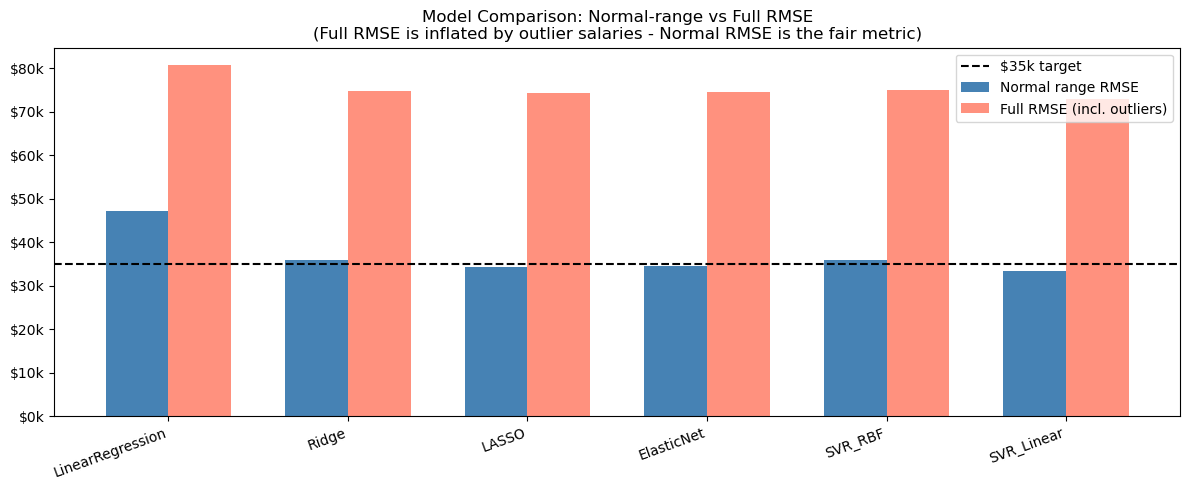

In [52]:
# Visual comparison
normal_rmse = {k: v['normal_RMSE'] for k, v in results.items()}
full_rmse   = {k: v['full_RMSE']   for k, v in results.items()}
models = list(normal_rmse.keys())

x = np.arange(len(models))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, [normal_rmse[m] for m in models], w,
            label='Normal range RMSE', color='steelblue')
b2 = ax.bar(x + w/2, [full_rmse[m]   for m in models], w,
            label='Full RMSE (incl. outliers)', color='tomato', alpha=0.7)
ax.axhline(35000, color='black', ls='--', label='$35k target')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.set_title('Model Comparison: Normal-range vs Full RMSE\n'
             '(Full RMSE is inflated by outlier salaries - Normal RMSE is the fair metric)')
ax.legend()
plt.tight_layout()
plt.show()

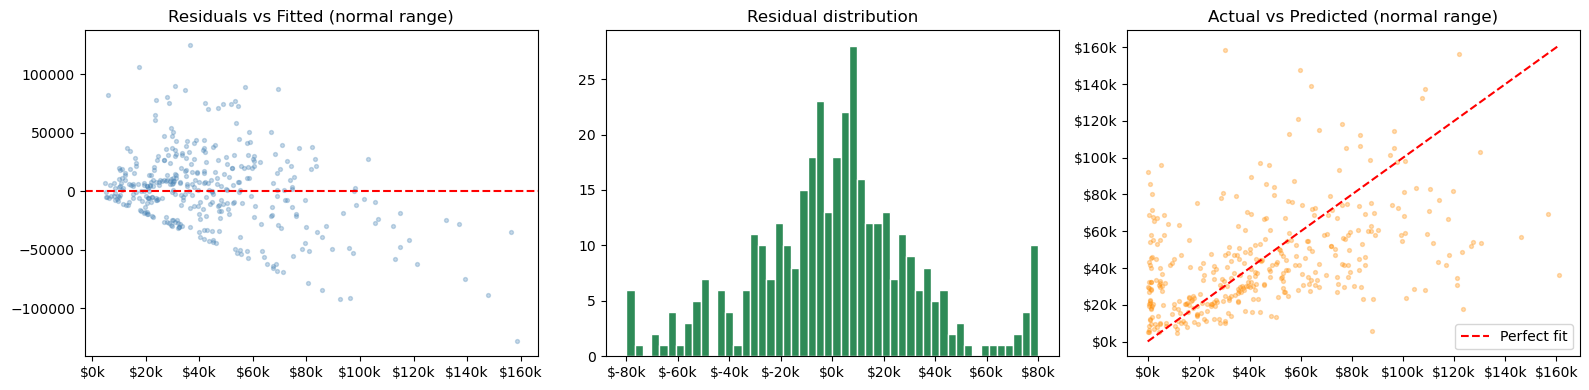

In [53]:
# Residual analysis on hold-out (normal range only)
best_model = results[best_name]['model']
y_pred_ho_log = best_model.predict(X_ho_s)

y_true_usd = np.expm1(y_ho)
y_pred_usd = np.expm1(np.clip(y_pred_ho_log, 0, 15))
mask_norm  = (y_true_usd >= LO) & (y_true_usd <= HI)
residuals  = y_true_usd[mask_norm] - y_pred_usd[mask_norm]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(y_pred_usd[mask_norm], residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuals vs Fitted (normal range)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

axes[1].hist(residuals.clip(-80000, 80000), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Residual distribution')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

axes[2].scatter(y_true_usd[mask_norm], y_pred_usd[mask_norm], alpha=0.3, s=8, color='darkorange')
lv = y_true_usd[mask_norm].min()
hv = y_true_usd[mask_norm].max()
axes[2].plot([lv, hv], [lv, hv], 'r--', label='Perfect fit')
axes[2].set_title('Actual vs Predicted (normal range)')
axes[2].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Retrain on Full Data & Generate Predictions

In [54]:
# Retrain on complete training set (all rows, including outliers)
X_full, rtm_full = build_features(train_full, is_train=True)
y_full = np.log1p(train_full['annual.pay.usd'])

imp_f = SimpleImputer(strategy='median', keep_empty_features=True)
X_full_i = pd.DataFrame(imp_f.fit_transform(X_full), columns=X_full.columns)
sc_f = RobustScaler()
X_full_s = sc_f.fit_transform(X_full_i)

final_model = clone(best_model)
final_model.fit(X_full_s, y_full)
print(f'Final model ({best_name}) retrained on {len(train_full):,} rows (incl. outliers)')

Final model (SVR_Linear) retrained on 2,512 rows (incl. outliers)


In [55]:
# Generate test predictions
X_test, _ = build_features(test_raw, is_train=False, region_target_map=rtm_full)
X_test    = X_test.reindex(columns=X_full.columns, fill_value=0)
X_test_i  = pd.DataFrame(imp_f.transform(X_test), columns=X_full.columns)
X_test_s  = sc_f.transform(X_test_i)

y_pred = np.expm1(np.clip(final_model.predict(X_test_s), 0, 15))

print(f'Predictions: mean=${y_pred.mean():,.0f}  '
      f'median=${np.median(y_pred):,.0f}  '
      f'min=${y_pred.min():,.0f}  max=${y_pred.max():,.0f}')

Predictions: mean=$43,910  median=$37,771  min=$3,228  max=$160,599


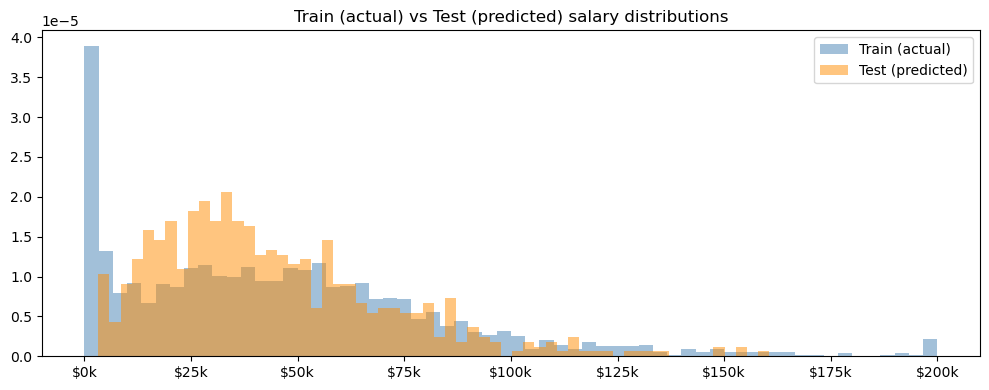

In [56]:
# Check predicted distribution vs training
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_full['annual.pay.usd'].clip(upper=200000),
        bins=60, alpha=0.5, color='steelblue', label='Train (actual)', density=True)
ax.hist(y_pred.clip(max=200000), bins=60, alpha=0.5,
        color='darkorange', label='Test (predicted)', density=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.set_title('Train (actual) vs Test (predicted) salary distributions')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Save Submission File

In [60]:
submission = pd.DataFrame({
    'id': test_raw['id'] if 'id' in test_raw.columns else range(len(test_raw)),
    'annual.pay.usd': y_pred
})
submission.to_csv('submission.csv', index=False)
print(f'Saved best_prediction.csv ({len(submission)} rows)')
print(submission.head(10).to_string(index=False))

Saved best_prediction.csv (628 rows)
 id  annual.pay.usd
  0    11840.275803
  1    22912.259711
  2    56058.610437
  3    85913.639013
  4    25973.492530
  5   154555.903103
  6    44962.346477
  7    54265.674227
  8    22236.398975
  9    34399.049072


## 10. Final Summary

In [59]:
print('=' * 65)
print('  FINAL SUMMARY (Full Training Data)')
print('=' * 65)
print()
print('KEY DESIGN DECISION')
print('  Outliers are KEPT in training so the model can learn from them.')
print('  RMSE is evaluated on the NORMAL SALARY RANGE only (0.5–99th pct)')
print('  because the full RMSE is dominated by extreme outlier errors and')
print('  gives a misleading picture of typical prediction quality.')
print()
print(f'Normal salary range : ${LO:,.0f} – ${HI:,.0f}')
print(f'Training rows       : {len(train_full):,} (all rows, no filtering)')
print(f'Feature count       : {X_full_s.shape[1]}')
print()
print('MODEL COMPARISON (sorted by Normal-range Holdout RMSE)')
for k, v in sorted(results.items(), key=lambda x: x[1]['normal_RMSE']):
    m = ' BEST' if k == best_name else '      '
    print(f'  {m} {k:<20} Normal: ${v["normal_RMSE"]:>8,.0f}   Full: ${v["full_RMSE"]:>8,.0f}')
print()
print(f'SELECTED MODEL  : {best_name}')
print(f'Expected RMSE   : ${results[best_name]["normal_RMSE"]:,.0f} (on normal-range salaries)')
print(f'OUTPUT FILE     : submission.csv')
print('=' * 65)

  FINAL SUMMARY (Full Training Data)

KEY DESIGN DECISION
  Outliers are KEPT in training so the model can learn from them.
  RMSE is evaluated on the NORMAL SALARY RANGE only (0.5–99th pct)
  because the full RMSE is dominated by extreme outlier errors and
  gives a misleading picture of typical prediction quality.

Normal salary range : $41 – $177,388
Training rows       : 2,512 (all rows, no filtering)
Feature count       : 329

MODEL COMPARISON (sorted by Normal-range Holdout RMSE)
   BEST SVR_Linear           Normal: $  33,368   Full: $  73,073
         LASSO                Normal: $  34,281   Full: $  74,408
         ElasticNet           Normal: $  34,506   Full: $  74,547
         Ridge                Normal: $  36,022   Full: $  74,925
         SVR_RBF              Normal: $  36,040   Full: $  74,931
         LinearRegression     Normal: $  47,152   Full: $  80,725

SELECTED MODEL  : SVR_Linear
Expected RMSE   : $33,368 (on normal-range salaries)
OUTPUT FILE     : submission.cs